In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs

%matplotlib inline

In [5]:
x, y = make_blobs(n_samples=1000, n_features=2, centers=3)

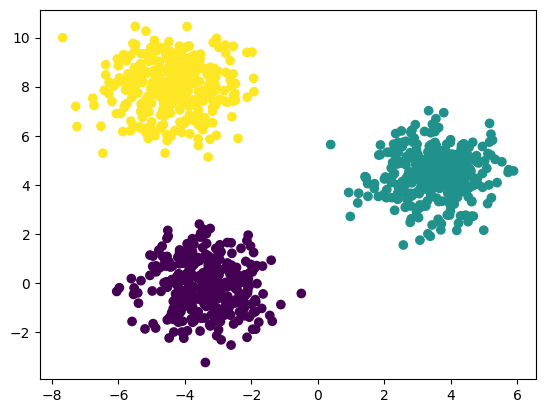

In [6]:
plt.scatter(x[:,0], x[:,1],c=y)

In [7]:
# standardization

from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
# train test split

from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [12]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
from sklearn.cluster import KMeans

In [14]:
# elbow method to select k value

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [15]:
wcss

[1340.0,
 697.02955229514,
 100.22320443178484,
 90.8008995052119,
 77.53410350959288,
 63.55347492830995,
 56.431405096606234,
 52.06580043141998,
 44.66399264017222,
 42.41700274869563]

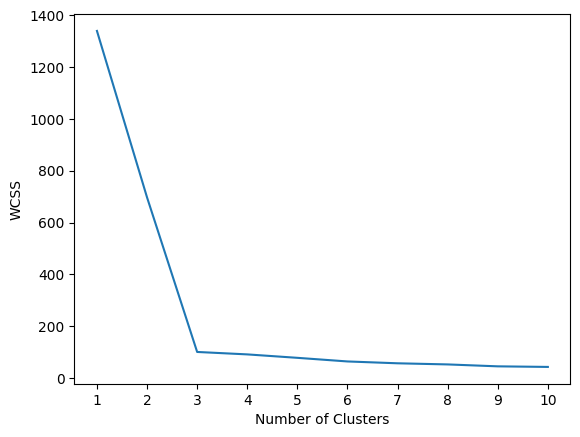

In [16]:
# plot the elbow curve

plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [19]:
kmeans.fit_predict(x_train_scaled)

array([1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 1, 2, 1, 2, 0, 1, 2,
       2, 0, 2, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 2,
       2, 0, 1, 0, 2, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 2, 2,
       0, 2, 1, 1, 0, 1, 0, 0, 1, 2, 0, 1, 0, 1, 1, 0, 2, 1, 2, 0, 1, 1,
       2, 1, 2, 2, 0, 2, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 1, 2, 0,
       0, 1, 2, 2, 0, 1, 0, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 0,
       1, 0, 2, 2, 0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1, 0, 0, 1, 0, 1, 2,
       2, 1, 1, 1, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 1, 1, 0,
       2, 0, 2, 1, 2, 1, 0, 2, 1, 1, 1, 2, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 0, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 1,
       1, 0, 2, 2, 2, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 1, 0, 1, 2, 2, 2,
       2, 0, 2, 1, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0,

In [20]:
y_pred = kmeans.predict(x_test_scaled)

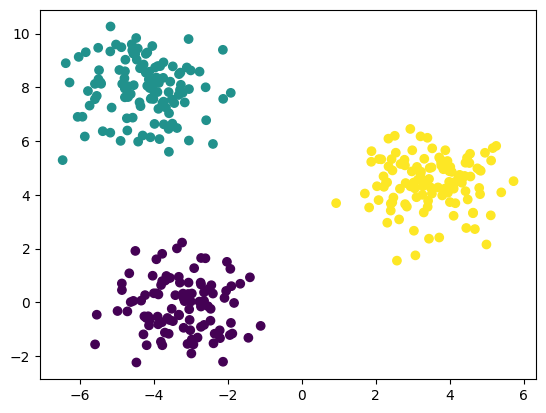

In [21]:
plt.scatter(x_test[:,0], x_test[:,1],c=y_pred)

In [24]:
# kneelocator

from kneed import KneeLocator

In [23]:
!pip install kneed

In [26]:
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')

In [27]:
kl.elbow

np.int64(3)

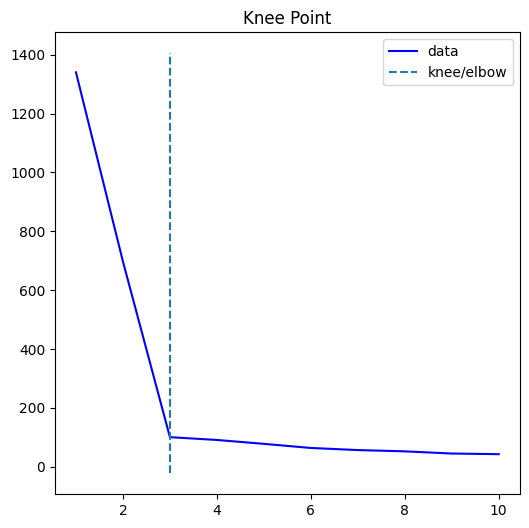

In [29]:
kl.plot_knee()

In [31]:
# silhoutee scoring

from sklearn.metrics import silhouette_score

In [33]:
silhouette_coeff = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train_scaled)
    score = silhouette_score(x_train_scaled, kmeans.labels_)
    silhouette_coeff.append(score)

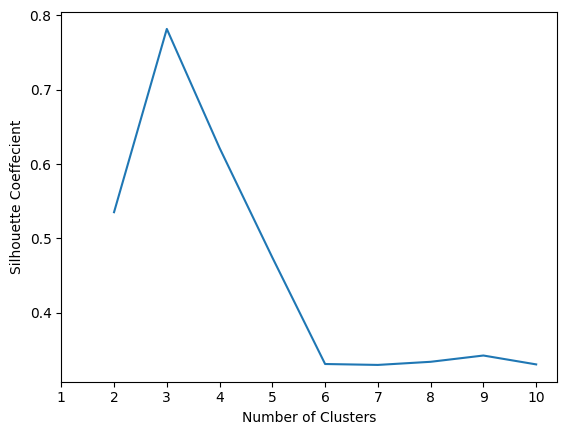

In [35]:
plt.plot(range(2, 11), silhouette_coeff)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coeffecient")
plt.show()